<a href="https://colab.research.google.com/github/i-malur/bootcamp-data-analytics-mod10/blob/main/m%C3%B3dulo_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IMPORTAÇÕES

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# AULA 01

In [2]:
df_carros = pd.read_csv('https://raw.githubusercontent.com/i-malur/bootcamp-data-analytics-mod10/refs/heads/main/carprices.csv')
df_carros.head()

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


In [3]:
rename_colunas = {
    "car_ID": "id_carro",
    "symboling": "classificacao_risco",
    "CarName": "nome_carro",
    "fueltype": "tipo_combustivel",
    "aspiration": "aspiracao",
    "doornumber": "numero_portas",
    "carbody": "tipo_carroceria",
    "drivewheel": "tracao",
    "enginelocation": "localizacao_motor",
    "wheelbase": "distancia_entre_eixos",
    "carlength": "comprimento",
    "carwidth": "largura",
    "carheight": "altura",
    "curbweight": "peso_total",
    "enginetype": "tipo_motor",
    "cylindernumber": "numero_cilindros",
    "enginesize": "tamanho_motor",
    "fuelsystem": "sistema_combustivel",
    "boreratio": "diametro_cilindro",
    "stroke": "curso_pistao",
    "compressionratio": "taxa_compressao",
    "horsepower": "potencia_hp",
    "peakrpm": "rpm_pico",
    "citympg": "consumo_cidade_mpg",
    "highwaympg": "consumo_estrada_mpg",
    "price": "preco",
}

df_carros = df_carros.rename(columns=rename_colunas)

In [4]:
df_carros.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id_carro               205 non-null    int64  
 1   classificacao_risco    205 non-null    int64  
 2   nome_carro             205 non-null    object 
 3   tipo_combustivel       205 non-null    object 
 4   aspiracao              205 non-null    object 
 5   numero_portas          205 non-null    object 
 6   tipo_carroceria        205 non-null    object 
 7   tracao                 205 non-null    object 
 8   localizacao_motor      205 non-null    object 
 9   distancia_entre_eixos  205 non-null    float64
 10  comprimento            205 non-null    float64
 11  largura                205 non-null    float64
 12  altura                 205 non-null    float64
 13  peso_total             205 non-null    int64  
 14  tipo_motor             205 non-null    object 
 15  numero

In [5]:
df_carros.describe()

,id_carro,classificacao_risco,distancia_entre_eixos,comprimento,largura,altura,peso_total,tamanho_motor,diametro_cilindro,curso_pistao,taxa_compressao,potencia_hp,rpm_pico,consumo_cidade_mpg,consumo_estrada_mpg,preco
count,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000
mean,103.000000,0.834146,98.756585,174.049268,65.907805,53.724878,2555.565854,126.907317,3.329756,3.255415,10.142537,104.117073,5125.121951,25.219512,30.751220,13276.710571
std,59.322565,1.245307,6.021776,12.337289,2.145204,2.443522,520.680204,41.642693,0.270844,0.313597,3.972040,39.544167,476.985643,6.542142,6.886443,7988.852332
min,1.000000,-2.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000
25%,52.000000,0.000000,94.500000,166.300000,64.100000,52.000000,2145.000000,97.000000,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000,7788.000000
50%,103.000000,1.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,3.310000,3.290000,9.000000,95.000000,5200.000000,24.000000,30.000000,10295.000000
75%,154.000000,2.000000,102.400000,183.100000,66.900000,55.500000,2935.000000,141.000000,3.580000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16503.000000
max,205.000000,3.000000,120.900000,208.100000,72.300000,59.800000,4066.000000,326.000000,3.940000,4.170000,23.000000,288.000000,6600.000000,49.000000,54.000000,45400.000000


## Análise de correlação

In [6]:
numericas = df_carros.select_dtypes(include=['float64', 'int64']) # apenas colunas numéricas
# matriz de correlação
corr = numericas.corr()

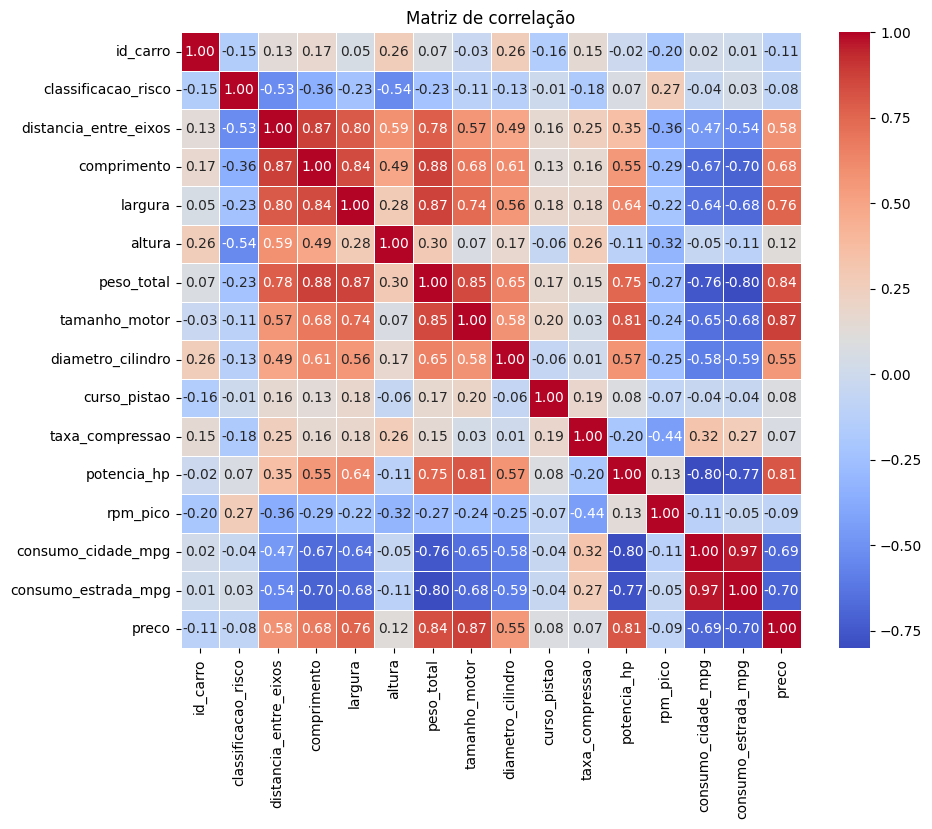

In [7]:
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Matriz de correlação')
plt.show()

## Análise dos gráficos de dispersão

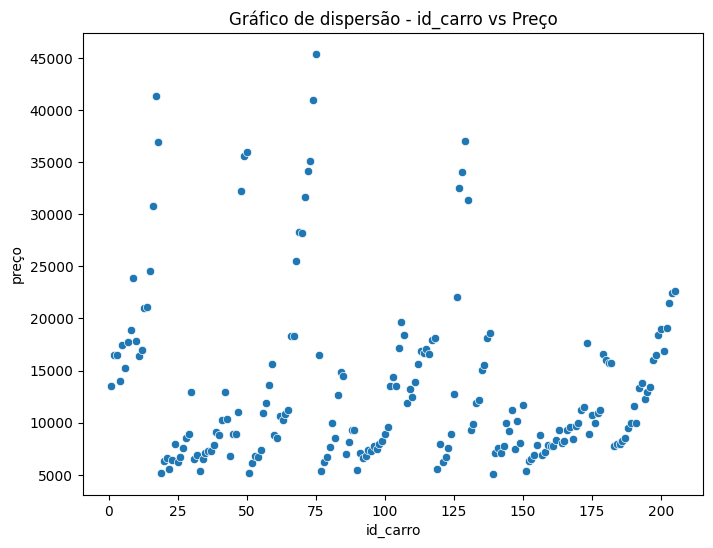

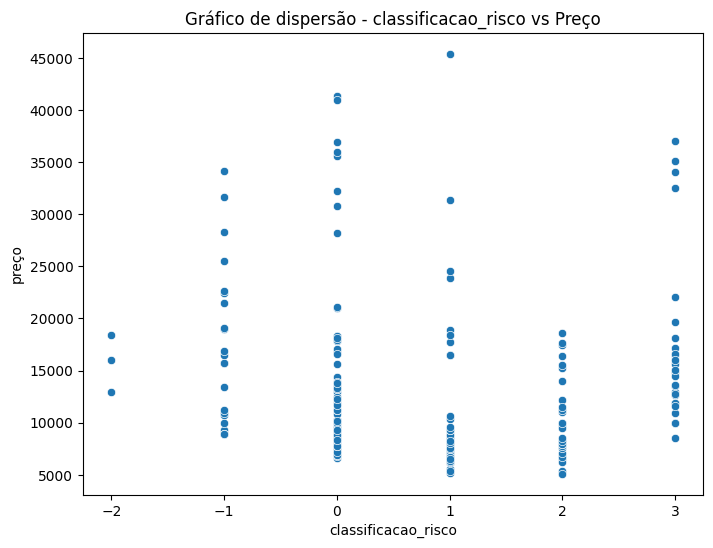

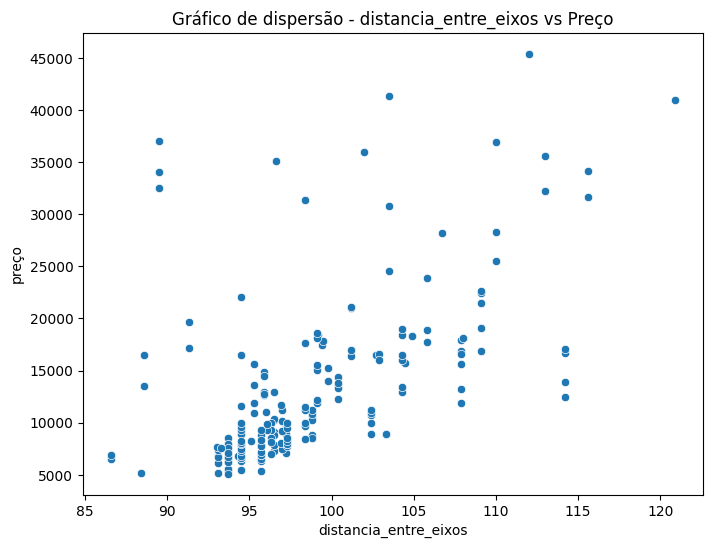

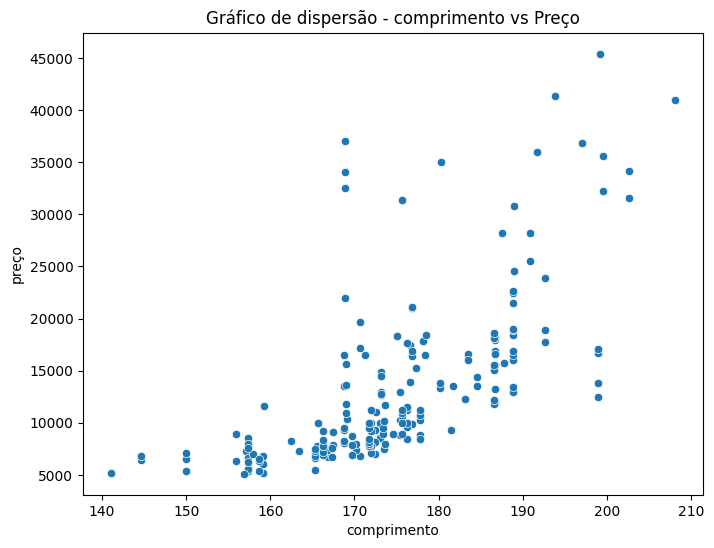

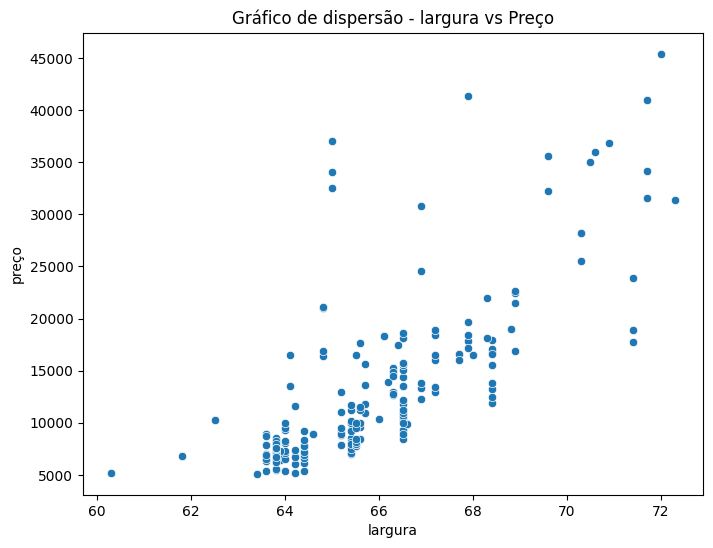

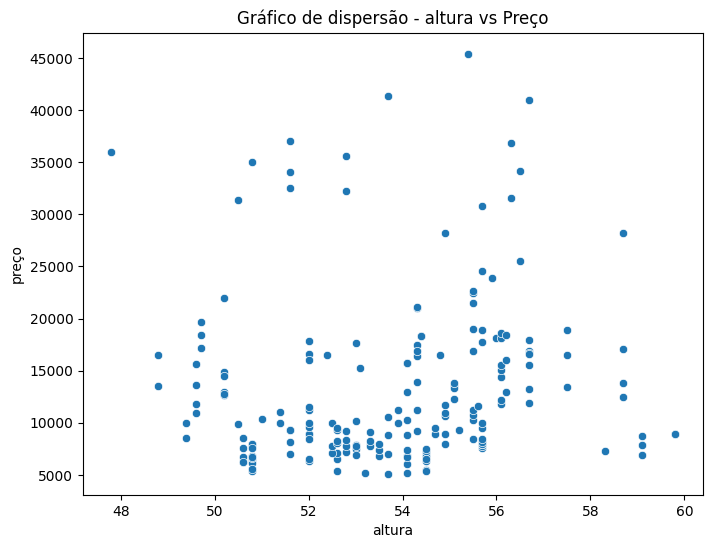

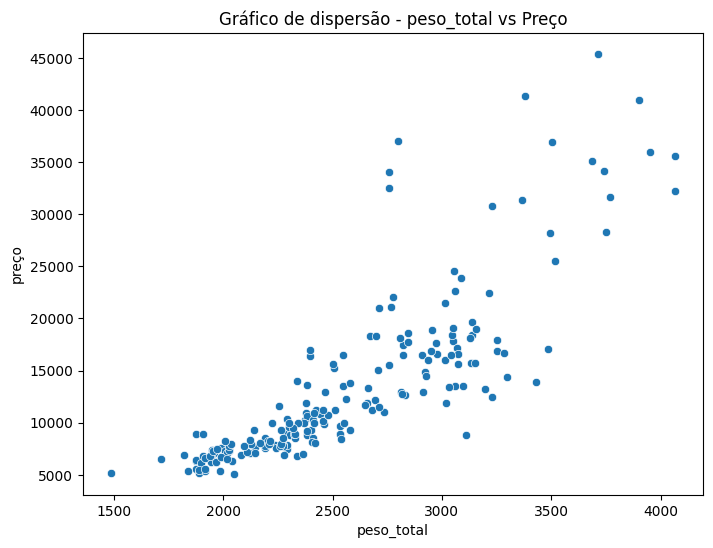

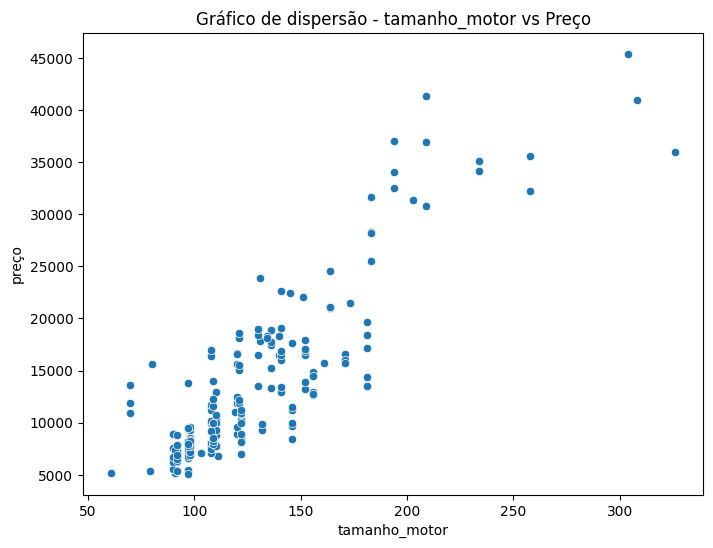

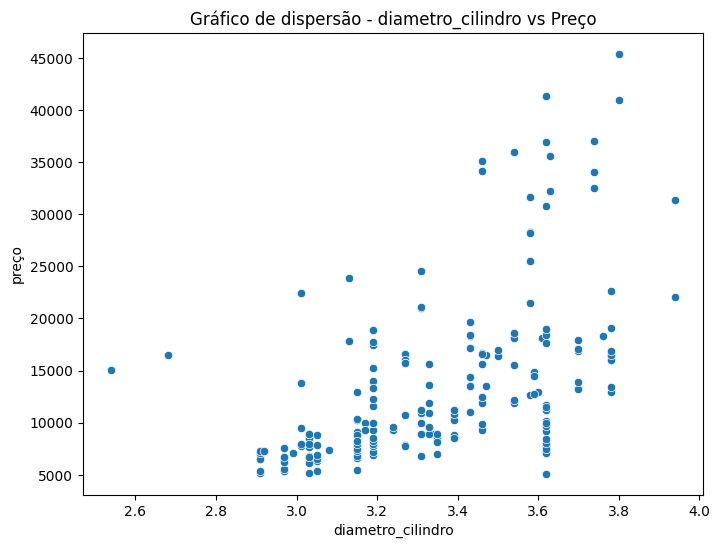

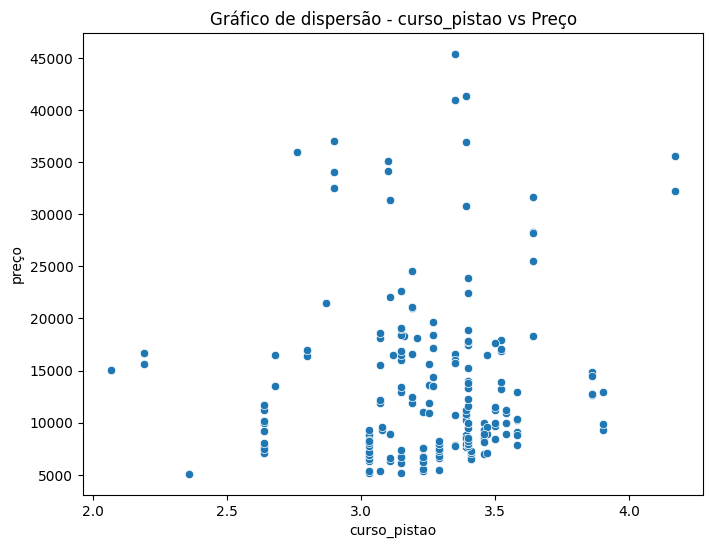

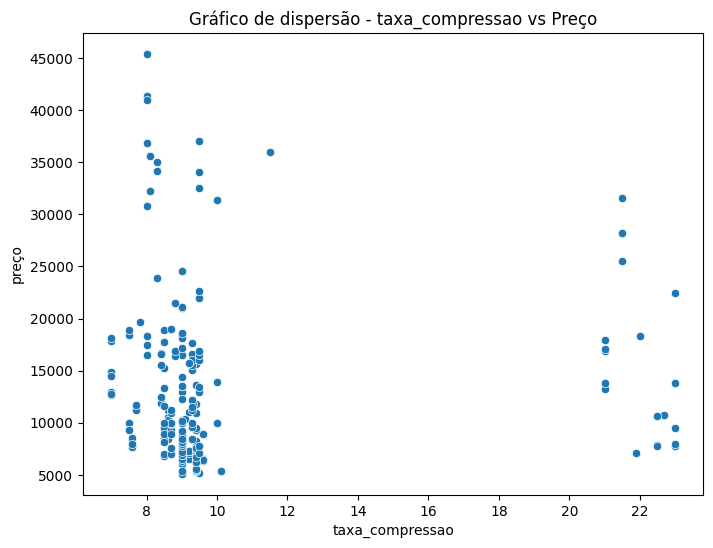

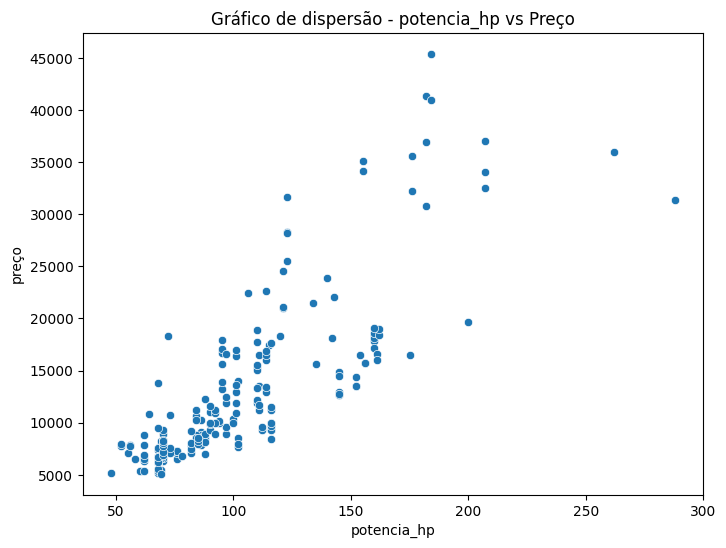

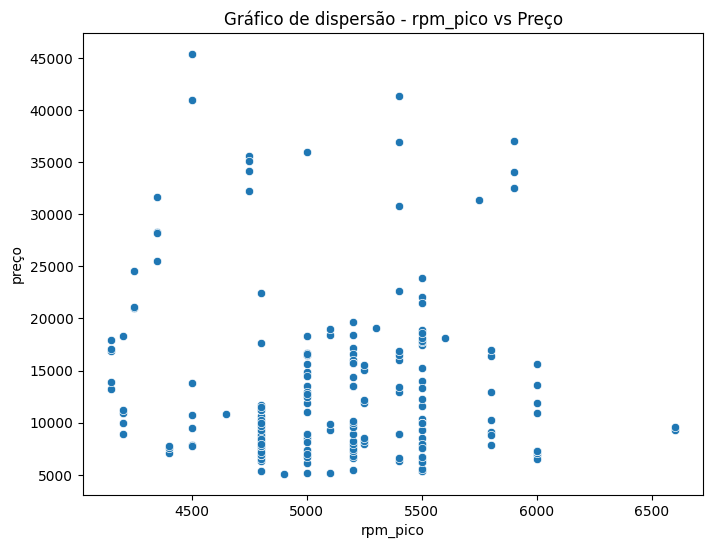

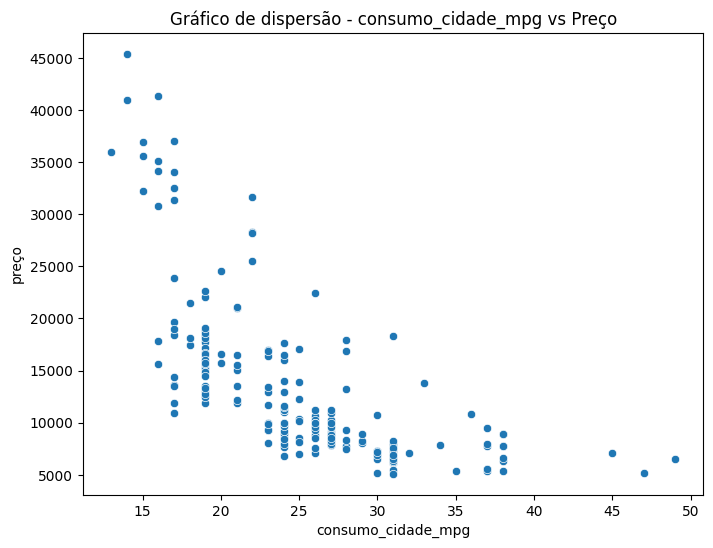

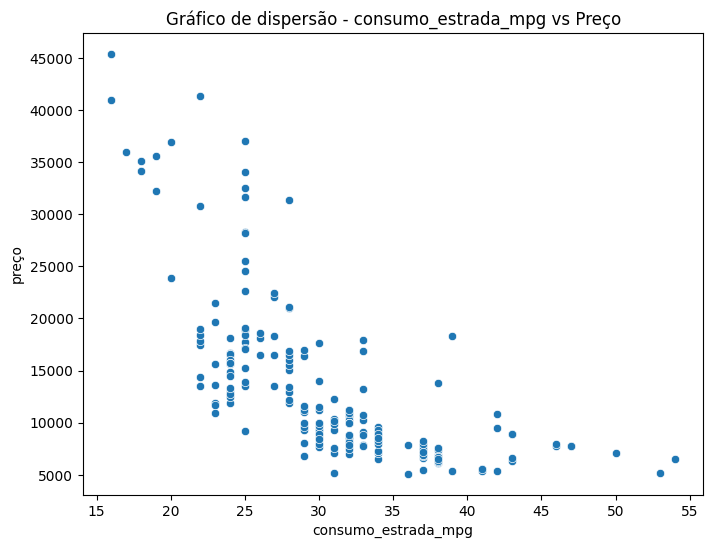

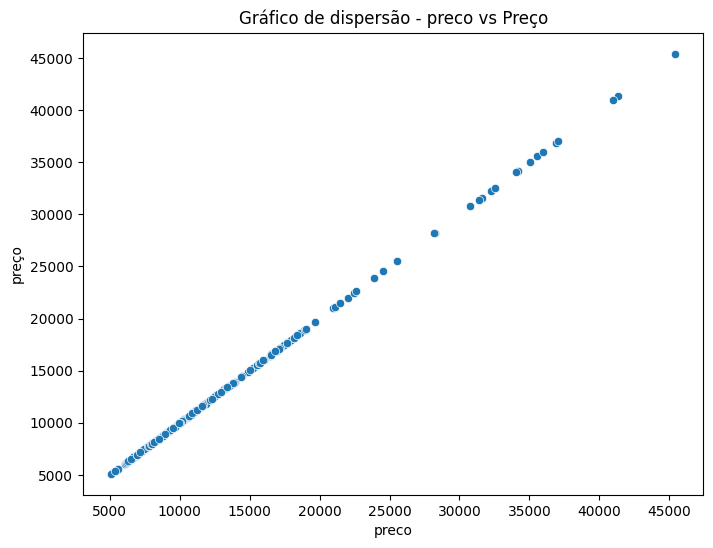

In [8]:
for column in numericas.columns:
  plt.figure(figsize=(8, 6))
  sns.scatterplot(data=numericas, x=column, y='preco')
  plt.title(f'Gráfico de dispersão - {column} vs Preço')
  plt.xlabel(column)
  plt.ylabel('preço')
  plt.show()

* notamos que algumas variáveis parecem ter uma relação bem linear com o preço. Vamos agora aplicar os conceitos de regressão linear simples

## Regressão linear simples: Preço vs Tamanho Motor

Considerando uma relação linear simples de preço e tamanho motor (enginesize). Pela matriz, a correlação é de 0.86, e o gráfico de dispersão apresentou boa relação.

In [9]:
import statsmodels.api as sm

In [10]:
# variável explicativa e constante
X = sm.add_constant(numericas['tamanho_motor'])

# variável de interesse
y = numericas['preco']

# fit do modelo: cálculo dos calores de intercepto e coeficiente angular estimados
model = sm.OLS(y, X).fit() # OLS -> minimos quadrados ordinários

# gera a tabela de regressão
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  preco   R-squared:                       0.764
Model:                            OLS   Adj. R-squared:                  0.763
Method:                 Least Squares   F-statistic:                     657.6
Date:                Tue, 04 Aug 2026   Prob (F-statistic):           1.35e-65
Time:                        16:45:47   Log-Likelihood:                -1984.4
No. Observations:                 205   AIC:                             3973.
Df Residuals:                     203   BIC:                             3979.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const         -8005.4455    873.221     -9.168

O modelo estimado é:

Preço do carro = -8005.445(coef) + 167.6984(tamanho do motor)

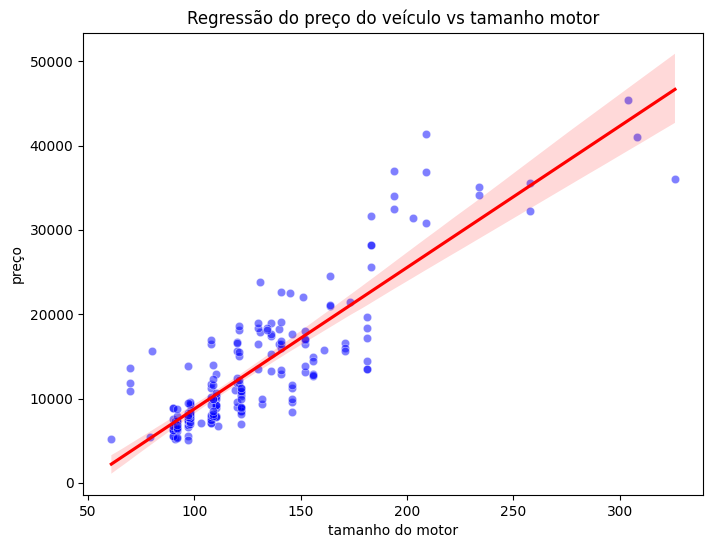

In [11]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=numericas, x='tamanho_motor', y='preco', color='blue', alpha=0.5)

# função regplot para gerar a regressão e plot da reta
sns.regplot(data=numericas, x='tamanho_motor', y='preco', scatter=False, color='red')

# títulos
plt.title('Regressão do preço do veículo vs tamanho motor')
plt.xlabel('tamanho do motor')
plt.ylabel('preço')
plt.show()

Analisando os resíduos do modelo

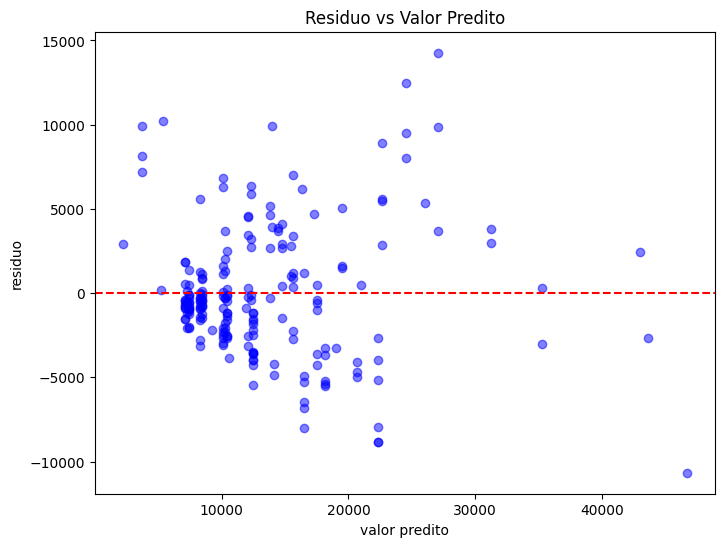

In [12]:
# salvando os resíduos
residuos = model.resid

# calcula o valor predito
valor_predito = model.fittedvalues

plt.figure(figsize=(8,6))
plt.scatter(valor_predito, residuos, color='blue', alpha=0.5)

# adiciona linha
plt.axhline(y=0, color='red', linestyle='--')

# títulos
plt.title('Residuo vs Valor Predito')
plt.xlabel('valor predito')
plt.ylabel('residuo')
plt.show()


## Regressão multipla

Para a regressão multipla, vamos considerar apenas as variáveis numéricas com alta correlação

In [13]:
# variáveis com alta correlação com preço
alta_correlacao = corr[(corr['preco'] > 0.7) | (corr['preco'] < -0.7)].index.tolist()
alta_correlacao.remove('preco')

# variaveis selecionadas
selecao_variaveis = ['preco'] + alta_correlacao
selecao_df = numericas[selecao_variaveis]

In [14]:
selecao_df.head()

,preco,largura,peso_total,tamanho_motor,potencia_hp
0,13495.0,64.1,2548,130,111
1,16500.0,64.1,2548,130,111
2,16500.0,65.5,2823,152,154
3,13950.0,66.2,2337,109,102
4,17450.0,66.4,2824,136,115


In [15]:
# fit do modelo
X = sm.add_constant(selecao_df.drop(columns=['preco']))
y = selecao_df['preco']
model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  preco   R-squared:                       0.820
Model:                            OLS   Adj. R-squared:                  0.816
Method:                 Least Squares   F-statistic:                     227.4
Date:                Tue, 04 Aug 2026   Prob (F-statistic):           3.15e-73
Time:                        16:45:48   Log-Likelihood:                -1956.8
No. Observations:                 205   AIC:                             3924.
Df Residuals:                     200   BIC:                             3940.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const         -4.623e+04   1.28e+04     -3.610

Vemos que peso_total possuo p-valor maior que 0.05. Assim, vamos remové-la do modelo.

In [16]:
alta_correlacao.remove('peso_total')

# variaveis re-selecionadas
selecao_variaveis = ['preco'] + alta_correlacao
selecao_df = numericas[selecao_variaveis]

In [17]:
# fit do modelo atualizado
X = sm.add_constant(selecao_df.drop(columns=['preco']))
y = selecao_df['preco']
model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  preco   R-squared:                       0.817
Model:                            OLS   Adj. R-squared:                  0.814
Method:                 Least Squares   F-statistic:                     298.9
Date:                Tue, 04 Aug 2026   Prob (F-statistic):           8.26e-74
Time:                        16:45:48   Log-Likelihood:                -1958.5
No. Observations:                 205   AIC:                             3925.
Df Residuals:                     201   BIC:                             3938.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const         -6.021e+04   1.02e+04     -5.889

Modelo estimado:

Preço do carro = -6.021e+04 (const) + 848.69 (largura do carro) + 94.94 (tamanho_motor) + 52.80 (poteência do carro)

Analisando os resíduos

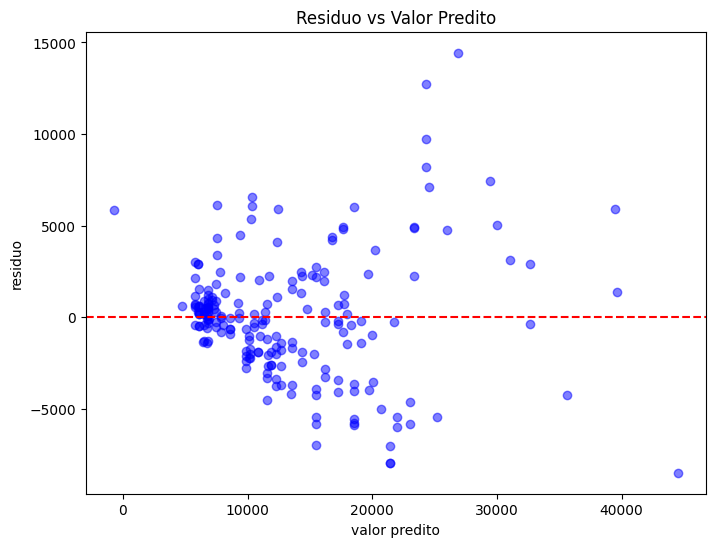

In [18]:
# salvando os resíduos
residuos = model.resid

# calcula o valor predito
valor_predito = model.fittedvalues

plt.figure(figsize=(8,6))
plt.scatter(valor_predito, residuos, color='blue', alpha=0.5)

# adiciona linha
plt.axhline(y=0, color='red', linestyle='--')

# títulos
plt.title('Residuo vs Valor Predito')
plt.xlabel('valor predito')
plt.ylabel('residuo')
plt.show()

# AULA 02

In [19]:
!pip install pydataset --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.9/15.9 MB 55.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [20]:
from pydataset import data
df = data('Journals')

initiated datasets repo at: /root/.pydataset/


In [21]:
data('Journals', show_doc=True)

Journals

PyDataset Documentation (adopted from R Documentation. The displayed examples are in R)

## Economic Journals Dat Set

### Description

a cross-section from 2000

_number of observations_ : 180

_observation_ : goods

### Usage

    data(Journals)

### Format

A dataframe containing :

title

journal title

pub

publisher

society

scholarly society ?

libprice

library subscription price

pages

number of pages

charpp

characters per page

citestot

total number of citations

date1

year journal was founded

oclc

number of library subscriptions

field

field description

### Source

Professor Theodore Bergstrom of the Department of Economics at the University
of California, San Diego.

### References

Stock, James H. and Mark W. Watson (2003) _Introduction to Econometrics_,
Addison-Wesley Educational Publishers,
http://wps.aw.com/aw_stockwatsn_economtrcs_1, chapter 6.

### See Also

`Index.Source`, `Index.Economics`, `Index.Econometrics`, `Index.Observations`




DataSet -> Journals

180 linhas com dados desde os anos 2000. São artigos da área de economia

Colunas:
* title: título do artigo
* publisher: editora da publicação
* society: sociedade acadêmica que publicou
* libprice: preço de assinatura para leitura
* pages: número de páginas
* charpp: número caracteres por página
* citestot: número de citações desse artigo
* datel: ano que o jornal foi fundundado
* oclc: número de assinantes
* field: área de estudo


### Análise preliminar dos dados

In [22]:
df.head()

,title,pub,society,libprice,pages,charpp,citestot,date1,oclc,field
1,Asian-Pacific Economic Literature,Blackwell,no,123,440,3822,21,1986,14,General
2,South African Journal of Economic History,So Afr ec history assn,no,20,309,1782,22,1986,59,Ec History
3,Computational Economics,Kluwer,no,443,567,2924,22,1987,17,Specialized
4,MOCT-MOST Economic Policy in Transitional Economics,Kluwer,no,276,520,3234,22,1991,2,Area Studies
5,Journal of Socio-Economics,Elsevier,no,295,791,3024,24,1972,96,Interdisciplinary


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 180 entries, 1 to 180
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   title     180 non-null    object
 1   pub       180 non-null    object
 2   society   180 non-null    object
 3   libprice  180 non-null    int64 
 4   pages     180 non-null    int64 
 5   charpp    180 non-null    int64 
 6   citestot  180 non-null    int64 
 7   date1     180 non-null    int64 
 8   oclc      180 non-null    int64 
 9   field     180 non-null    object
dtypes: int64(6), object(4)
memory usage: 15.5+ KB


### Variáveis numéricas

In [24]:
df.describe()

,libprice,pages,charpp,citestot,date1,oclc
count,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000
mean,417.722222,827.744444,3232.700000,647.055556,1966.905556,196.866667
std,385.834596,436.817402,819.358285,1182.373679,25.711484,204.528847
min,20.000000,167.000000,1782.000000,21.000000,1844.000000,2.000000
25%,134.500000,548.750000,2715.000000,97.750000,1962.750000,52.000000
50%,282.000000,693.000000,3010.000000,262.500000,1973.000000,122.500000
75%,540.750000,974.250000,3476.750000,656.000000,1982.250000,268.250000
max,2120.000000,2632.000000,6859.000000,8999.000000,1996.000000,1098.000000


In [25]:
numericas_df = df.select_dtypes(include=['float64', 'int64'])
corr = numericas_df.corr()

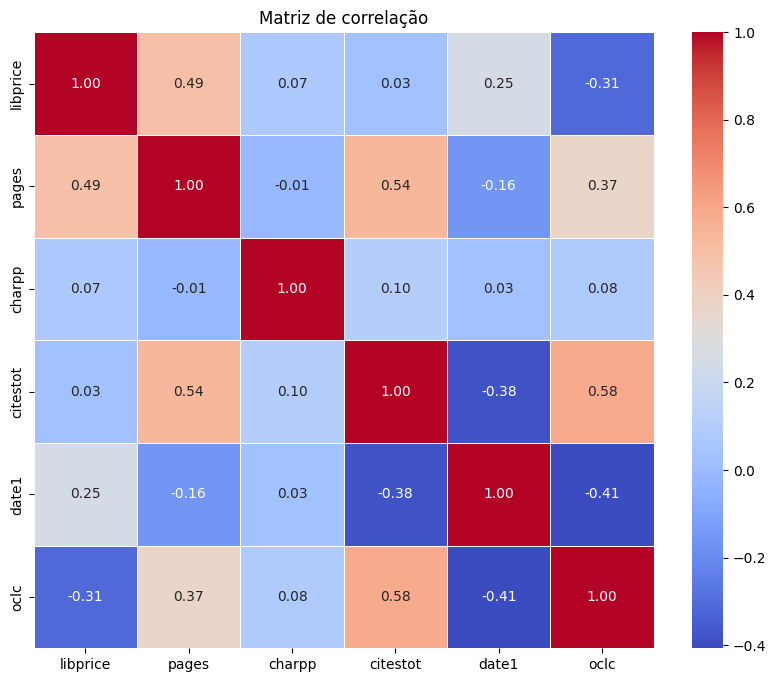

In [26]:
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Matriz de correlação')
plt.show()

Correlação elevada entre citesot (número de citações) e o número de subscrições oclc e número de páginas do artigo.

### Gráfico de dispersão PAIRPLOT emtre as numéricas

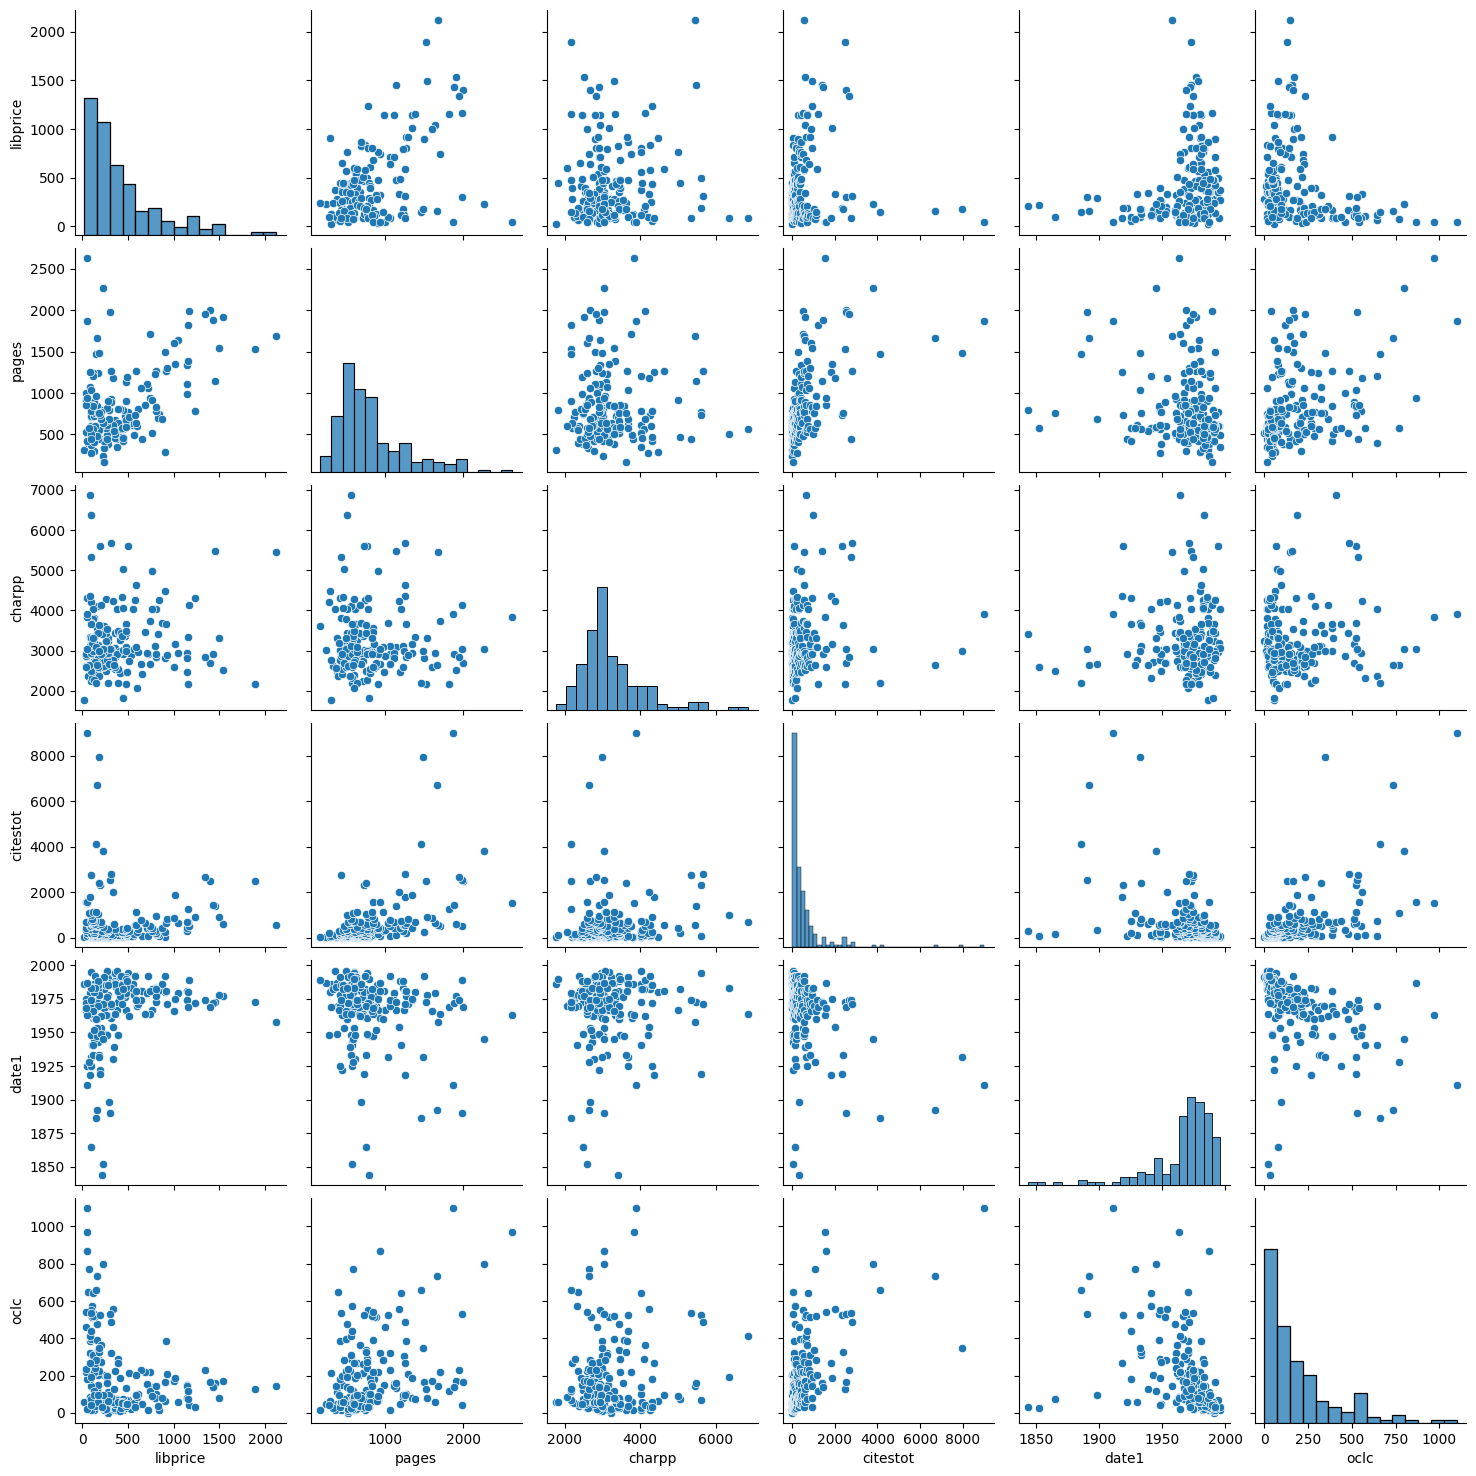

In [27]:
sns.pairplot(numericas_df, diag_kind='hist')

### Análise das variáveis categóricas

#### Análise de correspondência

In [28]:
df.head()

,title,pub,society,libprice,pages,charpp,citestot,date1,oclc,field
1,Asian-Pacific Economic Literature,Blackwell,no,123,440,3822,21,1986,14,General
2,South African Journal of Economic History,So Afr ec history assn,no,20,309,1782,22,1986,59,Ec History
3,Computational Economics,Kluwer,no,443,567,2924,22,1987,17,Specialized
4,MOCT-MOST Economic Policy in Transitional Economics,Kluwer,no,276,520,3234,22,1991,2,Area Studies
5,Journal of Socio-Economics,Elsevier,no,295,791,3024,24,1972,96,Interdisciplinary


categóricas: pub (editora), field (área de estudo) e society (indica se foi publicado por uma sociedade acadêmica). title se comporta mais como variável ID.

In [29]:
# cardinalidade de editora
# cardinalidade -> número de categorias na coluna
df['pub'].nunique()

52

In [30]:
# cardinalidade de campo de atuação
# cardinalidade -> número de categorias na coluna
df['field'].nunique()

24

In [31]:
# cardinalidade de sociedade
# cardinalidade -> número de categorias na coluna
df['society'].nunique()

2

pub e field tem muitas cardinalidades, nesse caso, vamos retacalogar os dados em top categorias

analise do campo de editora

In [32]:
contagens = df['pub'].value_counts()

# top 5 categorias
top_categorias = contagens.head(5).index.tolist()

# muda o nome das categorias diferentes das top para outras
df['pub'] = df['pub'].apply(lambda x: x if x in top_categorias else 'Outra')

In [33]:
df['pub'].value_counts()

,count
pub,
Outra,77
Elsevier,42
Blackwell,26
Kluwer,16
Springer,10
Academic Press,9


analise do campo de atuação

In [34]:
contagens = df['field'].value_counts()

# top 5 categorias
top_categorias = contagens.head(5).index.tolist()

# muda o nome das categorias diferentes das top para outras
df['field'] = df['field'].apply(lambda x: x if x in top_categorias else 'Outra')

In [35]:
df['field'].value_counts()

,count
field,
Outra,92
General,40
Specialized,14
Public Finance,12
Development,11
Finance,11


Plotando gráficos

/tmp/ipykernel_787/4040667685.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(df, x='pub', palette=palette).set_title('Contagem de editoras')


Text(0.5, 1.0, 'Contagem de editoras')

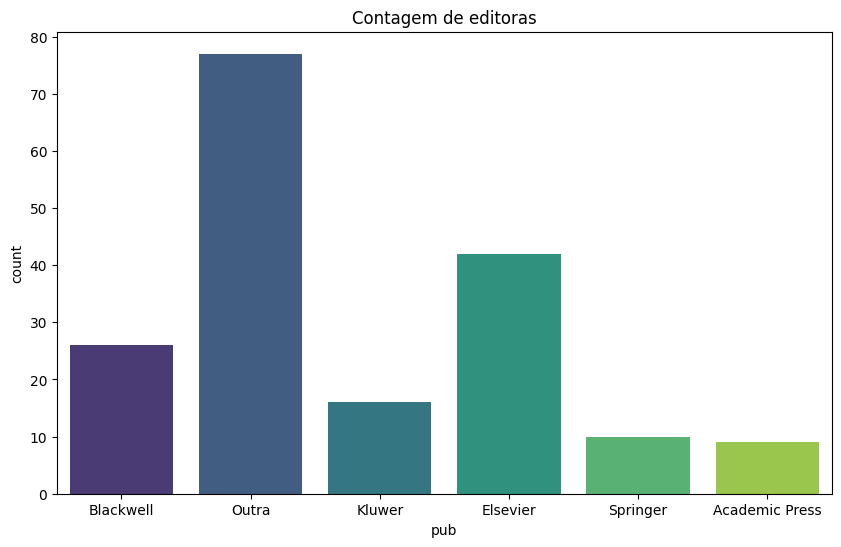

In [36]:
palette = sns.color_palette('viridis', len(df['pub'].unique()))

plt.figure(figsize=(10,6))
sns.countplot(df, x='pub', palette=palette).set_title('Contagem de editoras')

/tmp/ipykernel_787/44904570.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(df, x='pub', palette=palette).set_title('Contagem de áreas de atuação')


Text(0.5, 1.0, 'Contagem de áreas de atuação')

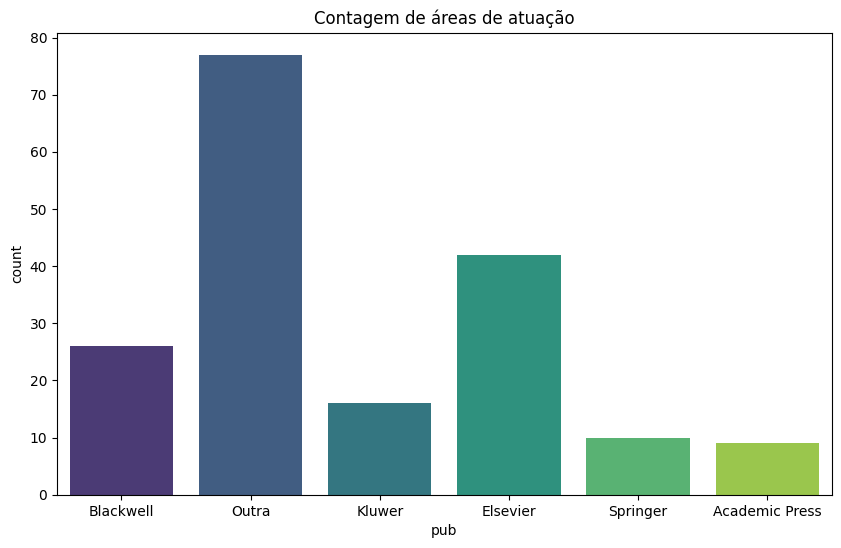

In [37]:
palette = sns.color_palette('viridis', len(df['field'].unique()))

plt.figure(figsize=(10,6))
sns.countplot(df, x='pub', palette=palette).set_title('Contagem de áreas de atuação')

Correlação entre categóricas - tabela de contingência

In [38]:
from scipy.stats import chi2_contingency

In [39]:
# tabela de contigencia
tabela = pd.crosstab(df['pub'], df['field'])

print('Tabela de contingência')
print(tabela)

Tabela de contingência
field           Development  Finance  General  Outra  Public Finance  \
pub                                                                    
Academic Press            0        1        0      7               0   
Blackwell                 4        0       14      6               1   
Elsevier                  2        4        3     27               1   
Kluwer                    0        0        2     12               1   
Outra                     5        4       20     35               8   
Springer                  0        2        1      5               1   

field           Specialized  
pub                          
Academic Press            1  
Blackwell                 1  
Elsevier                  5  
Kluwer                    1  
Outra                     5  
Springer                  1  


In [40]:
# analise das frequencias de linhas
perc_linhas = tabela.div(tabela.sum(axis=1), axis=0) * 100
print('Frequências')
print(perc_linhas)

Frequências
field           Development    Finance    General      Outra  Public Finance  \
pub                                                                            
Academic Press     0.000000  11.111111   0.000000  77.777778        0.000000   
Blackwell         15.384615   0.000000  53.846154  23.076923        3.846154   
Elsevier           4.761905   9.523810   7.142857  64.285714        2.380952   
Kluwer             0.000000   0.000000  12.500000  75.000000        6.250000   
Outra              6.493506   5.194805  25.974026  45.454545       10.389610   
Springer           0.000000  20.000000  10.000000  50.000000       10.000000   

field           Specialized  
pub                          
Academic Press    11.111111  
Blackwell          3.846154  
Elsevier          11.904762  
Kluwer             6.250000  
Outra              6.493506  
Springer          10.000000  


In [41]:
# teste qui-quadrado

chi2, p, dof, expected = chi2_contingency(tabela)

In [42]:
print('estatística do teste qui-quadrado')
chi2

estatística do teste qui-quadrado


np.float64(47.40409816750161)

In [43]:
print('p-valor')
p

p-valor


np.float64(0.004392265383396728)

h0: as variáveis não se relacionam   
h1: as variáveis se relacionam

como p-valor é < 0.05, podemos rejeitar h0.

### Interação numéricas e categóricas

In [44]:
df.columns

Index(['title', 'pub', 'society', 'libprice', 'pages', 'charpp', 'citestot',
       'date1', 'oclc', 'field'],
      dtype='object')

Text(0.5, 1.0, 'Preço da publicação por editora')

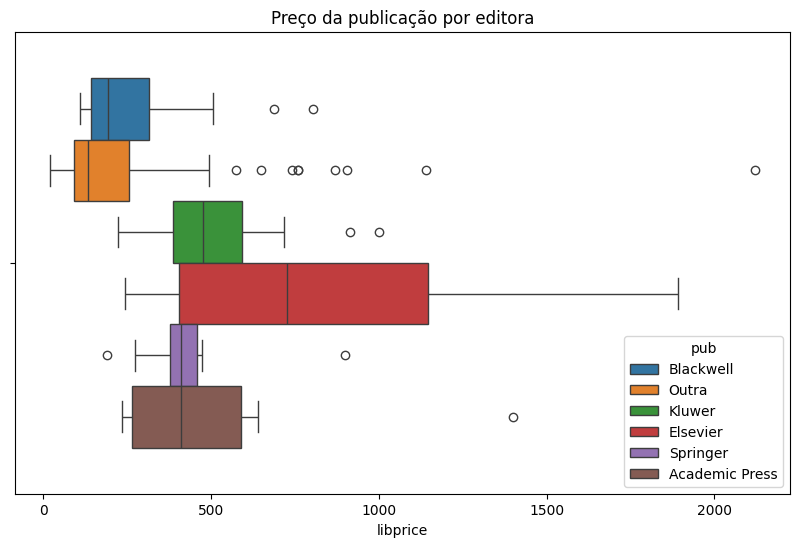

In [45]:
plt.figure(figsize=(10, 6))
sns.boxplot(df, x='libprice', hue='pub').set_title('Preço da publicação por editora')

A editora elsevier tem um preço maior para os artigos acadêmicos

Text(0.5, 1.0, 'Numero de citações por editora')

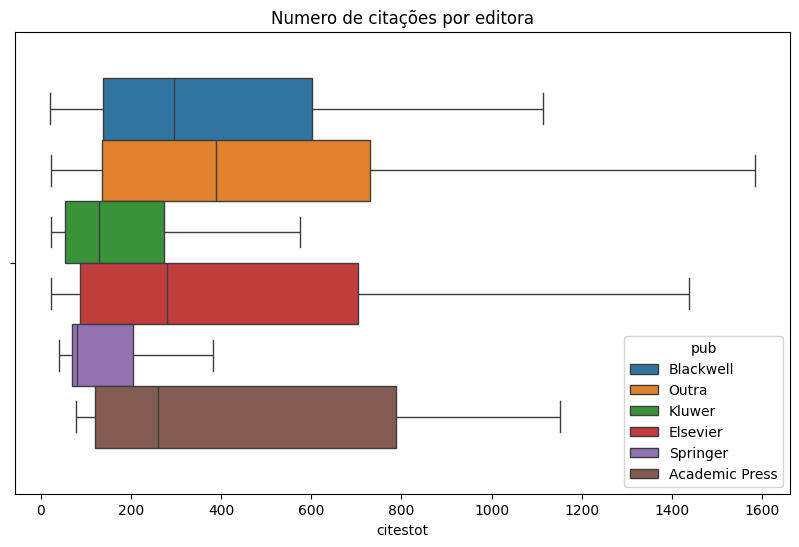

In [48]:
plt.figure(figsize=(10, 6))
sns.boxplot(df, x='citestot', hue='pub', showfliers=False).set_title('Numero de citações por editora')

A editora elsevier e backwell tem maiores medianas de número de citações, mas, a academic press tem uma maior massa de artigos concentrada de 300 a 800 citações.

## Modelos de regresssão e categóricas

* vamos prever o número de citações
* nesse caso excluiremos o título, pois, ele atua como id

In [49]:
df.drop('title', axis=1, inplace=True)

In [50]:
df.dtypes

,0
pub,object
society,object
libprice,int64
pages,int64
charpp,int64
citestot,int64
date1,int64
oclc,int64
field,object


usando get dummies para transformar as categóricas em numéricas para usar a regressão

In [51]:
# utilizando o pacote pd get dummies
df_dummies = pd.get_dummies(df).astype(int)

In [54]:
df.head()

,pub,society,libprice,pages,charpp,citestot,date1,oclc,field
1,Blackwell,no,123,440,3822,21,1986,14,General
2,Outra,no,20,309,1782,22,1986,59,Outra
3,Kluwer,no,443,567,2924,22,1987,17,Specialized
4,Kluwer,no,276,520,3234,22,1991,2,Outra
5,Elsevier,no,295,791,3024,24,1972,96,Outra


In [53]:
df_dummies.head()

,libprice,pages,charpp,citestot,date1,oclc,pub_Academic Press,pub_Blackwell,pub_Elsevier,pub_Kluwer,pub_Outra,pub_Springer,society_no,society_yes,field_Development,field_Finance,field_General,field_Outra,field_Public Finance,field_Specialized
1,123,440,3822,21,1986,14,0,1,0,0,0,0,1,0,0,0,1,0,0,0
2,20,309,1782,22,1986,59,0,0,0,0,1,0,1,0,0,0,0,1,0,0
3,443,567,2924,22,1987,17,0,0,0,1,0,0,1,0,0,0,0,0,0,1
4,276,520,3234,22,1991,2,0,0,0,1,0,0,1,0,0,0,0,1,0,0
5,295,791,3024,24,1972,96,0,0,1,0,0,0,1,0,0,0,0,1,0,0


Regressão simples

In [55]:
# OLS

# import do pacote
import statsmodels.api as sm

# define a variável explicativa e adiciona uma constante
X = sm.add_constant(df_dummies['pages'])

# define a variável de interesse
y = df_dummies['citestot']

In [56]:
# fit do modelo
model = sm.OLS(y, X).fit()

In [57]:
# gera a tabela
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               citestot   R-squared:                       0.288
Model:                            OLS   Adj. R-squared:                  0.284
Method:                 Least Squares   F-statistic:                     72.13
Date:                Tue, 04 Aug 2026   Prob (F-statistic):           7.77e-15
Time:                        16:57:34   Log-Likelihood:                -1497.8
No. Observations:                 180   AIC:                             3000.
Df Residuals:                     178   BIC:                             3006.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       -556.1284    160.085     -3.474      0.0

Rquadrado baixo: relação não parece completamente linear / explicada

## Regressão multipla com eliminação recursiva

In [58]:
# define função para eliminação recursiva das variáveis explicativas com base no p-valor
# variáveis com p-valor > 0.05 são removidas
def OLS_RFE(X, y, threshold=0.05):
  while True:
    model = sm.OLS(y, X).fit()
    p_values = model.pvalues
    max_p_values = p_values.max()
    if max_p_values > threshold:
      remove_feature = p_values.idxmax()
      X = X.drop(remove_feature, axis=1)
    else:
      break
  return model, X.columns

In [61]:
# aplica a função e imprime a tabela de regressão
X = df_dummies.drop(['citestot', 'society_no', 'society_yes'], axis=1)
y = df_dummies['citestot']

final_model, selected_features = OLS_RFE(X, y)

print('variáveis selecionadas', selected_features)
print('\n\n tabela de regressão')
print(final_model.summary())

variáveis selecionadas Index(['pages', 'date1', 'oclc', 'pub_Academic Press', 'pub_Blackwell',
       'pub_Elsevier', 'pub_Kluwer', 'pub_Outra', 'pub_Springer'],
      dtype='object')


 tabela de regressão
                            OLS Regression Results                            
Dep. Variable:               citestot   R-squared:                       0.492
Model:                            OLS   Adj. R-squared:                  0.468
Method:                 Least Squares   F-statistic:                     20.68
Date:                Tue, 04 Aug 2026   Prob (F-statistic):           1.02e-21
Time:                        17:08:40   Log-Likelihood:                -1467.5
No. Observations:                 180   AIC:                             2953.
Df Residuals:                     171   BIC:                             2982.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
   

removendo variáveis que se complementam (society_no e society_yes).

verificando resíduos

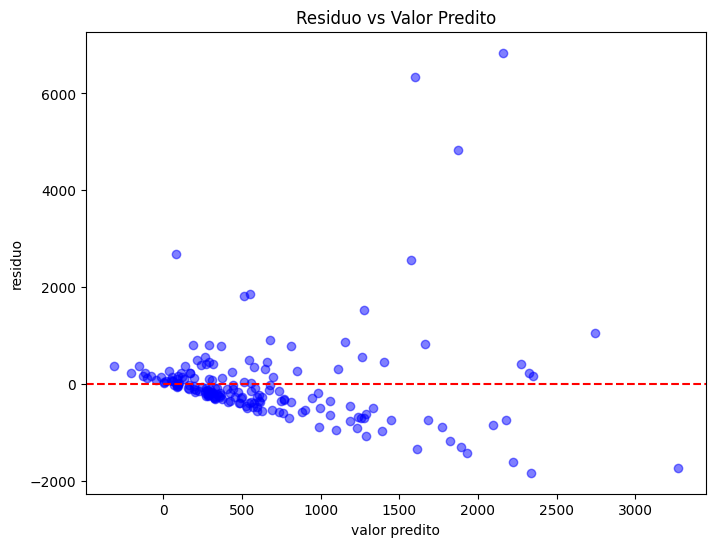

In [62]:
# salvando os resíduos
residuos = model.resid

# calcula o valor predito
valor_predito = model.fittedvalues

plt.figure(figsize=(8,6))
plt.scatter(valor_predito, residuos, color='blue', alpha=0.5)

# adiciona linha
plt.axhline(y=0, color='red', linestyle='--')

# títulos
plt.title('Residuo vs Valor Predito')
plt.xlabel('valor predito')
plt.ylabel('residuo')
plt.show()

formato de cone: valores que vão crescendo, com variância inconstante. O modelo pode ser usado, porém, não é o adequado.

temos um dataset com poucas observações, seria necessário mais observações.